In [1]:
! pip install faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 865.7 kB/s eta 0:00:02
   --------------- ------------------------ 0.8/2.0 MB 1.1 MB/s eta 0:00:02
   --------------------- ------------------ 1.0/2.0 MB 992.1 kB/s eta 0:00:01
   -------------------------- ------------- 1.3/2.0 MB 1.0 MB/s eta 0:00:01
   ------------------------------- -------- 1.6/2.0 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 1.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from faker import Faker
import numpy as np
import pandas as pd
import random


In [6]:
fake=Faker()

In [4]:
categories = ["Electronics", "Clothing", "Home", "Books", "Sports"]

data = []

In [7]:
for i in range(500):
    order = {
        "order_id": i + 1,
        "order_date": fake.date_between(start_date='-1y', end_date='today'),
        "customer_id": fake.random_int(min=1000, max=9999),
        "product_category": random.choice(categories),
        "price": round(random.uniform(100, 5000), 2),
        "quantity": random.randint(1, 5),
        "discount_percent": random.choice([0, 5, 10, 15, 20, 25])
    }
    data.append(order)

In [8]:
df=pd.DataFrame(data)
df.head()

,order_id,order_date,customer_id,product_category,price,quantity,discount_percent
0,1,2025-05-31,4946,Clothing,4354.02,3,0
1,2,2025-06-07,6844,Clothing,134.61,3,5
2,3,2025-04-23,8857,Sports,811.59,3,5
3,4,2026-03-04,1588,Clothing,867.98,2,5
4,5,2025-07-10,5236,Books,2036.27,3,5


In [9]:
df['final_amount']=df['price']*df['quantity']*(1-df['discount_percent']/100)

In [10]:
df.head()

,order_id,order_date,customer_id,product_category,price,quantity,discount_percent,final_amount
0,1,2025-05-31,4946,Clothing,4354.02,3,0,13062.0600
1,2,2025-06-07,6844,Clothing,134.61,3,5,383.6385
2,3,2025-04-23,8857,Sports,811.59,3,5,2313.0315
3,4,2026-03-04,1588,Clothing,867.98,2,5,1649.1620
4,5,2025-07-10,5236,Books,2036.27,3,5,5803.3695


In [13]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.to_period("M")

monthly_revenue = df.groupby(["month", "product_category"])["final_amount"].sum().reset_index()

monthly_revenue.head()

,month,product_category,final_amount
0,2025-03,Books,8574.4980
1,2025-03,Clothing,18170.6575
2,2025-03,Home,30812.6935
3,2025-03,Sports,8061.9355
4,2025-04,Books,72506.7025


In [14]:
top_categories = (
    df.groupby("product_category")["final_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

print("Top 3 Categories:\n", top_categories)

Top 3 Categories:
 product_category
Home        722532.6840
Sports      645886.1515
Clothing    630385.9215
Name: final_amount, dtype: float64


In [15]:
mean = np.mean(df["final_amount"])
std = np.std(df["final_amount"])

df["z_score"] = (df["final_amount"] - mean) / std


threshold = 3

df["is_anomaly"] = np.abs(df["z_score"]) > threshold

print(df[df["is_anomaly"]])

     order_id order_date  customer_id product_category    price  quantity  \
14         15 2025-04-24         1278         Clothing  4797.35         5   
143       144 2026-03-27         7626            Books  4843.15         5   
414       415 2025-06-25         8442      Electronics  4963.86         5   

     discount_percent  final_amount    month   z_score  is_anomaly  
14                  5    22787.4125  2025-04  3.132946        True  
143                 0    24215.7500  2026-03  3.405880        True  
414                 5    23578.3350  2025-06  3.284079        True  


In [16]:
median_value = df["final_amount"].median()

df.loc[df["is_anomaly"], "final_amount"] = median_value

In [17]:
import matplotlib.pyplot as plt

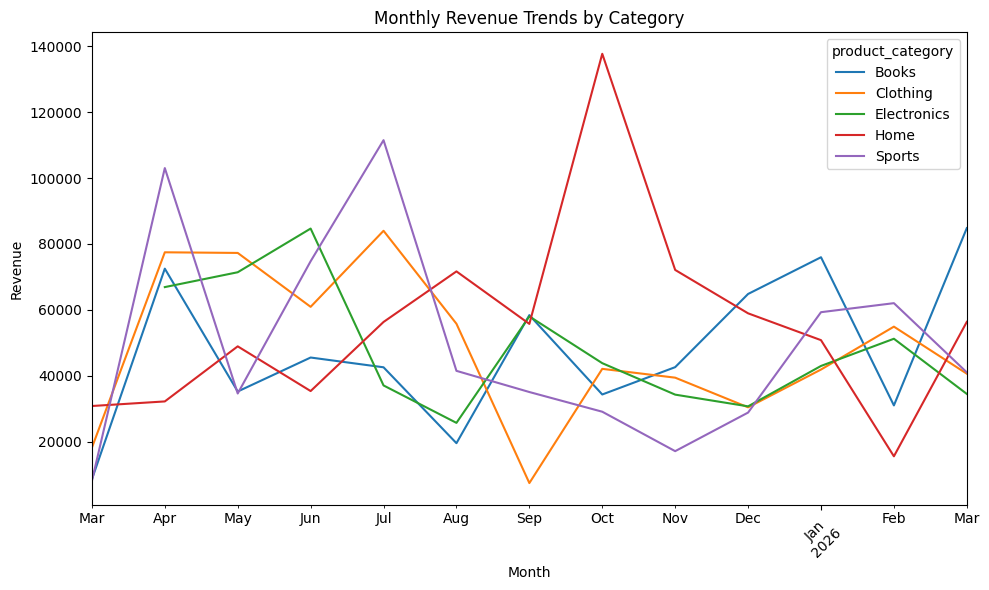

In [18]:
pivot_table = monthly_revenue.pivot(index="month", columns="product_category", values="final_amount")

pivot_table.plot(figsize=(10, 6))
plt.title("Monthly Revenue Trends by Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

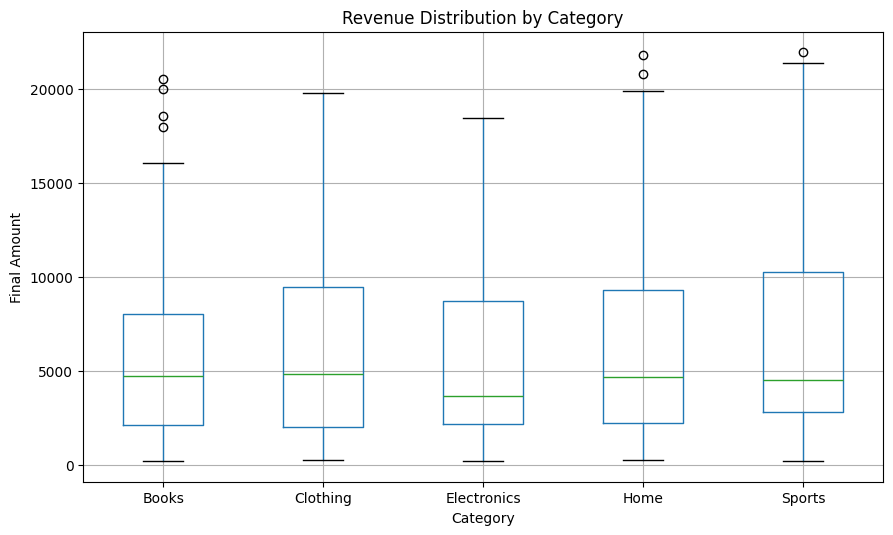

In [19]:
df.boxplot(column="final_amount", by="product_category", figsize=(10, 6))
plt.title("Revenue Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Final Amount")
plt.show()